# Initation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline
# to visualise al the columns in the dataframe
pd.pandas.set_option('display.max_columns', None)

In [ ]:
dataset=pd.read_csv('adult.csv' , on_bad_lines='skip')
dataset.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
# Row count
row_original_count = dataset.shape[0]
row_original_count

48842

In [ ]:
dataset.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

# **Missing Value**

<Axes: >

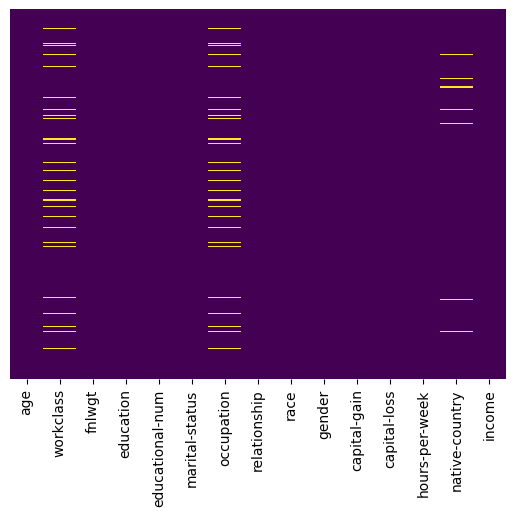

In [ ]:
dataset.replace("?", pd.NA, inplace=True)
sns.heatmap(dataset.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [ ]:
dataset

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,<NA>,103497,Some-college,10,Never-married,<NA>,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
## List all categorical features which are missing
categorical_columns = dataset.select_dtypes(include=['object']).columns
print(categorical_columns)

for i in categorical_columns:
    missing_percent = (dataset[i].isnull().sum() / len(dataset))*100
    if missing_percent > 0:
        print(f"{i}: {missing_percent:.8f}% missing values")

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country', 'income'],
      dtype='object')
workclass: 5.73072356% missing values
occupation: 5.75119774% missing values
native-country: 1.75463740% missing values


In [ ]:
## List all numerical features which are missing
numerical_columns = dataset.select_dtypes(exclude=['object']).columns
print(numerical_columns)

for i in numerical_columns:
    missing_percent = (dataset[i].isnull().sum() / len(dataset))*100
    if missing_percent > 0:
        print(f"{i}: {missing_percent:.8f}% missing values")

Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')


# Clean data

In [ ]:

dataset_cleaned = dataset.copy()
dataset_cleaned = dataset_cleaned.dropna()

# ถ้าแก้หมดต้องไม่มีอะไรออกมา
for i in categorical_columns:
    missing_percent = (dataset_cleaned[i].isnull().sum() / len(dataset))
    if missing_percent > 0:
        print(f"{i}: {missing_percent:.4f}% missing values")

for i in numerical_columns:
    missing_percent = (dataset[i].isnull().sum() / len(dataset))*100
    if missing_percent > 0:
        print(f"{i}: {missing_percent:.8f}% missing values")

In [ ]:
dataset_cleaned

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


# Outlier statistic

In [ ]:
import pandas as pd

def calculate_outliers(dataframe):
    numerical_columns = dataset.select_dtypes(exclude=['object']).columns

    for column in numerical_columns:
        series = dataframe[column]
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        lower_outliers = series[series < lower_bound]
        upper_outliers = series[series > upper_bound]

        total_lower_outliers = len(lower_outliers)
        total_upper_outliers = len(upper_outliers)
        total_outliers = total_lower_outliers + total_upper_outliers

        print(f"Column -> {column}: Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}, "
              f"Q1-1.5IQR: {lower_bound:.2f}, Q3+1.5IQR: {upper_bound:.2f}, "
              f"Total upper outliers: {total_upper_outliers}, "
              f"Total lower outliers: {total_lower_outliers}, "
              f"Total outliers: {total_outliers}")

calculate_outliers(dataset_cleaned)


Column -> age: Q1: 28.00, Q3: 47.00, IQR: 19.00, Q1-1.5IQR: -0.50, Q3+1.5IQR: 75.50, Total upper outliers: 269, Total lower outliers: 0, Total outliers: 269
Column -> fnlwgt: Q1: 117388.25, Q3: 237926.00, IQR: 120537.75, Q1-1.5IQR: -63418.38, Q3+1.5IQR: 418732.62, Total upper outliers: 1331, Total lower outliers: 0, Total outliers: 1331
Column -> educational-num: Q1: 9.00, Q3: 13.00, IQR: 4.00, Q1-1.5IQR: 3.00, Q3+1.5IQR: 19.00, Total upper outliers: 0, Total lower outliers: 294, Total outliers: 294
Column -> capital-gain: Q1: 0.00, Q3: 0.00, IQR: 0.00, Q1-1.5IQR: 0.00, Q3+1.5IQR: 0.00, Total upper outliers: 3790, Total lower outliers: 0, Total outliers: 3790
Column -> capital-loss: Q1: 0.00, Q3: 0.00, IQR: 0.00, Q1-1.5IQR: 0.00, Q3+1.5IQR: 0.00, Total upper outliers: 2140, Total lower outliers: 0, Total outliers: 2140
Column -> hours-per-week: Q1: 40.00, Q3: 45.00, IQR: 5.00, Q1-1.5IQR: 32.50, Q3+1.5IQR: 52.50, Total upper outliers: 4981, Total lower outliers: 6918, Total outliers: 11

# Remove outlier

In [ ]:
## Total row before outlier clean

total_rows_before_outlier_clean = dataset_cleaned.shape[0]

# Display the total number of rows
print("Total number of rows:", total_rows_before_outlier_clean)

Total number of rows: 45222


## Normal Outlier drop

In [ ]:
## Now lets check for numerical variables
numerical_columns = dataset.select_dtypes(exclude=['object']).columns
numerical_columns

Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [ ]:
def remove_outliers(dataset, numerical_columns):
    dataset_cleaned = dataset.copy()

    # Iterate through numerical columns
    for column in numerical_columns:
        Q1 = dataset_cleaned[column].quantile(0.25)
        Q3 = dataset_cleaned[column].quantile(0.75)

        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = (dataset_cleaned[column] < lower_bound) | (dataset_cleaned[column] > upper_bound)

        dataset_cleaned = dataset_cleaned[~outliers]

    return dataset_cleaned

dataset_no_outliers = remove_outliers(dataset_cleaned, numerical_columns)


dataset_no_outliers

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
11,36,Federal-gov,212465,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48835,53,Private,321865,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
48836,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K


## Remove special for capital-gain and capital-loss

In [ ]:
def remove_zero_capital_columns(dataset):
    dataset_cleaned = dataset.copy()

    # Drop rows where 'capital-gain' or 'capital-loss' is less than or equal to 0
    dataset_cleaned = dataset_cleaned[(dataset_cleaned['capital-gain'] > 0) | (dataset_cleaned['capital-loss'] > 0)]


    return dataset_cleaned

data_no_zero_capital = remove_zero_capital_columns(dataset_cleaned)
# data_no_zero_capital = remove_outliers(data_no_zero_capital, numerical_columns)
data_no_zero_capital




,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
10,65,Private,184454,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,6418,0,40,United-States,>50K
14,48,Private,279724,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,3103,0,48,United-States,>50K
25,45,Self-emp-not-inc,432824,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,7298,0,90,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48796,66,Federal-gov,47358,10th,6,Married-civ-spouse,Craft-repair,Husband,White,Male,3471,0,40,United-States,<=50K
48799,57,Local-gov,110417,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,99999,0,40,United-States,>50K
48819,38,Private,139180,Bachelors,13,Divorced,Prof-specialty,Unmarried,Black,Female,15020,0,45,United-States,>50K
48829,65,Self-emp-not-inc,99359,Prof-school,15,Never-married,Prof-specialty,Not-in-family,White,Male,1086,0,60,United-States,<=50K


# Processing categorical and/or numerical data

## Explain how you do transformation (categorical => numerical, or numerical => categorical)

### Convert for income ไม่รู้ใช้อันไหน เลยใส่ไปสองแบบเลย

In [ ]:
from sklearn.preprocessing import LabelEncoder
income_mapping = {'<=50K': 0, '>50K': 1}
dataset_no_outliers['numeric-income'] = dataset_no_outliers['income'].map(income_mapping)
dataset_no_outliers


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,numeric-income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,1
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K,0
11,36,Federal-gov,212465,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,<=50K,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48835,53,Private,321865,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K,1
48836,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K,0
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K,1


In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
dataset_no_outliers['Income-numeric-labelencoder'] = label_encoder.fit_transform(dataset_no_outliers['income'])
dataset_no_outliers

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,numeric-income,Income-numeric-labelencoder
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,1,1
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K,0,0
11,36,Federal-gov,212465,Bachelors,13,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,<=50K,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48835,53,Private,321865,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K,1,1
48836,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K,0,0
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K,0,0
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K,1,1


# Feature scaling

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

def min_max_scaling(dataset, numerical_columns):
    dataset_scaled = dataset.copy()
    scaler = MinMaxScaler()

    dataset_scaled[numerical_columns] = scaler.fit_transform(dataset_scaled[numerical_columns])

    return dataset_scaled

dataset_normalized = min_max_scaling(dataset_no_outliers, numerical_columns)

dataset_normalized


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,numeric-income,Income-numeric-labelencoder
0,0.137931,Private,0.525518,11th,0.307692,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,0.368421,United-States,<=50K,0,0
1,0.362069,Private,0.187591,HS-grad,0.461538,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,0.894737,United-States,<=50K,0,0
2,0.189655,Local-gov,0.797238,Assoc-acdm,0.692308,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,0.368421,United-States,>50K,1,1
8,0.120690,Private,0.877943,Some-college,0.538462,Never-married,Other-service,Unmarried,White,Female,0.0,0.0,0.368421,United-States,<=50K,0,0
11,0.327586,Federal-gov,0.490151,Bachelors,0.769231,Married-civ-spouse,Adm-clerical,Husband,White,Male,0.0,0.0,0.368421,United-States,<=50K,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48835,0.620690,Private,0.760023,Masters,0.846154,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,0.368421,United-States,>50K,1,1
48836,0.086207,Private,0.731129,Some-college,0.538462,Never-married,Protective-serv,Not-in-family,White,Male,0.0,0.0,0.368421,United-States,<=50K,0,0
48837,0.172414,Private,0.600757,Assoc-acdm,0.692308,Married-civ-spouse,Tech-support,Wife,White,Female,0.0,0.0,0.263158,United-States,<=50K,0,0
48838,0.396552,Private,0.346850,HS-grad,0.461538,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0.0,0.0,0.368421,United-States,>50K,1,1


# Give summary statistics of Adult Dataset

## Show all มาก่อนเผื่อเจออะไรน่าสนใจ (Can't use anyting?)

### Already scaling

In [ ]:
# sns.pairplot(dataset_normalized)
# plt.show()

### Pre scaling

In [ ]:
# sns.pairplot(dataset_no_outliers)
# plt.show()

## Use the Adult data set, where the target variable is income, and the goal is to classify income based on  the other variables

## Distribution of age with income per annual.

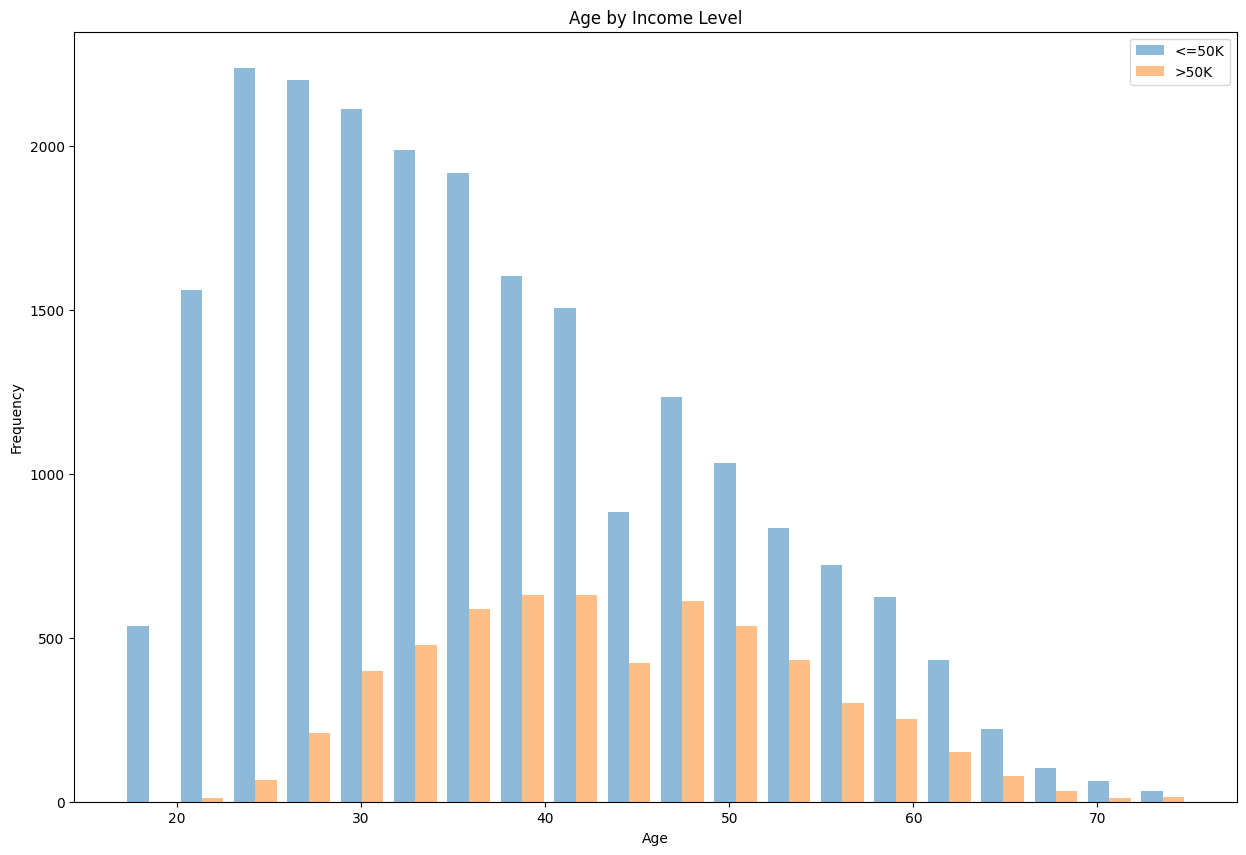

In [ ]:
plt.figure(figsize=(15, 10))
plt.hist([dataset_no_outliers[dataset_no_outliers['numeric-income'] == 0]['age'], dataset_no_outliers[dataset_no_outliers['numeric-income'] == 1]['age']],
         bins=20, alpha=0.5, label=['<=50K', '>50K'])

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age by Income Level')
plt.legend()

plt.show()

## Distribution of workclass with income per annual.

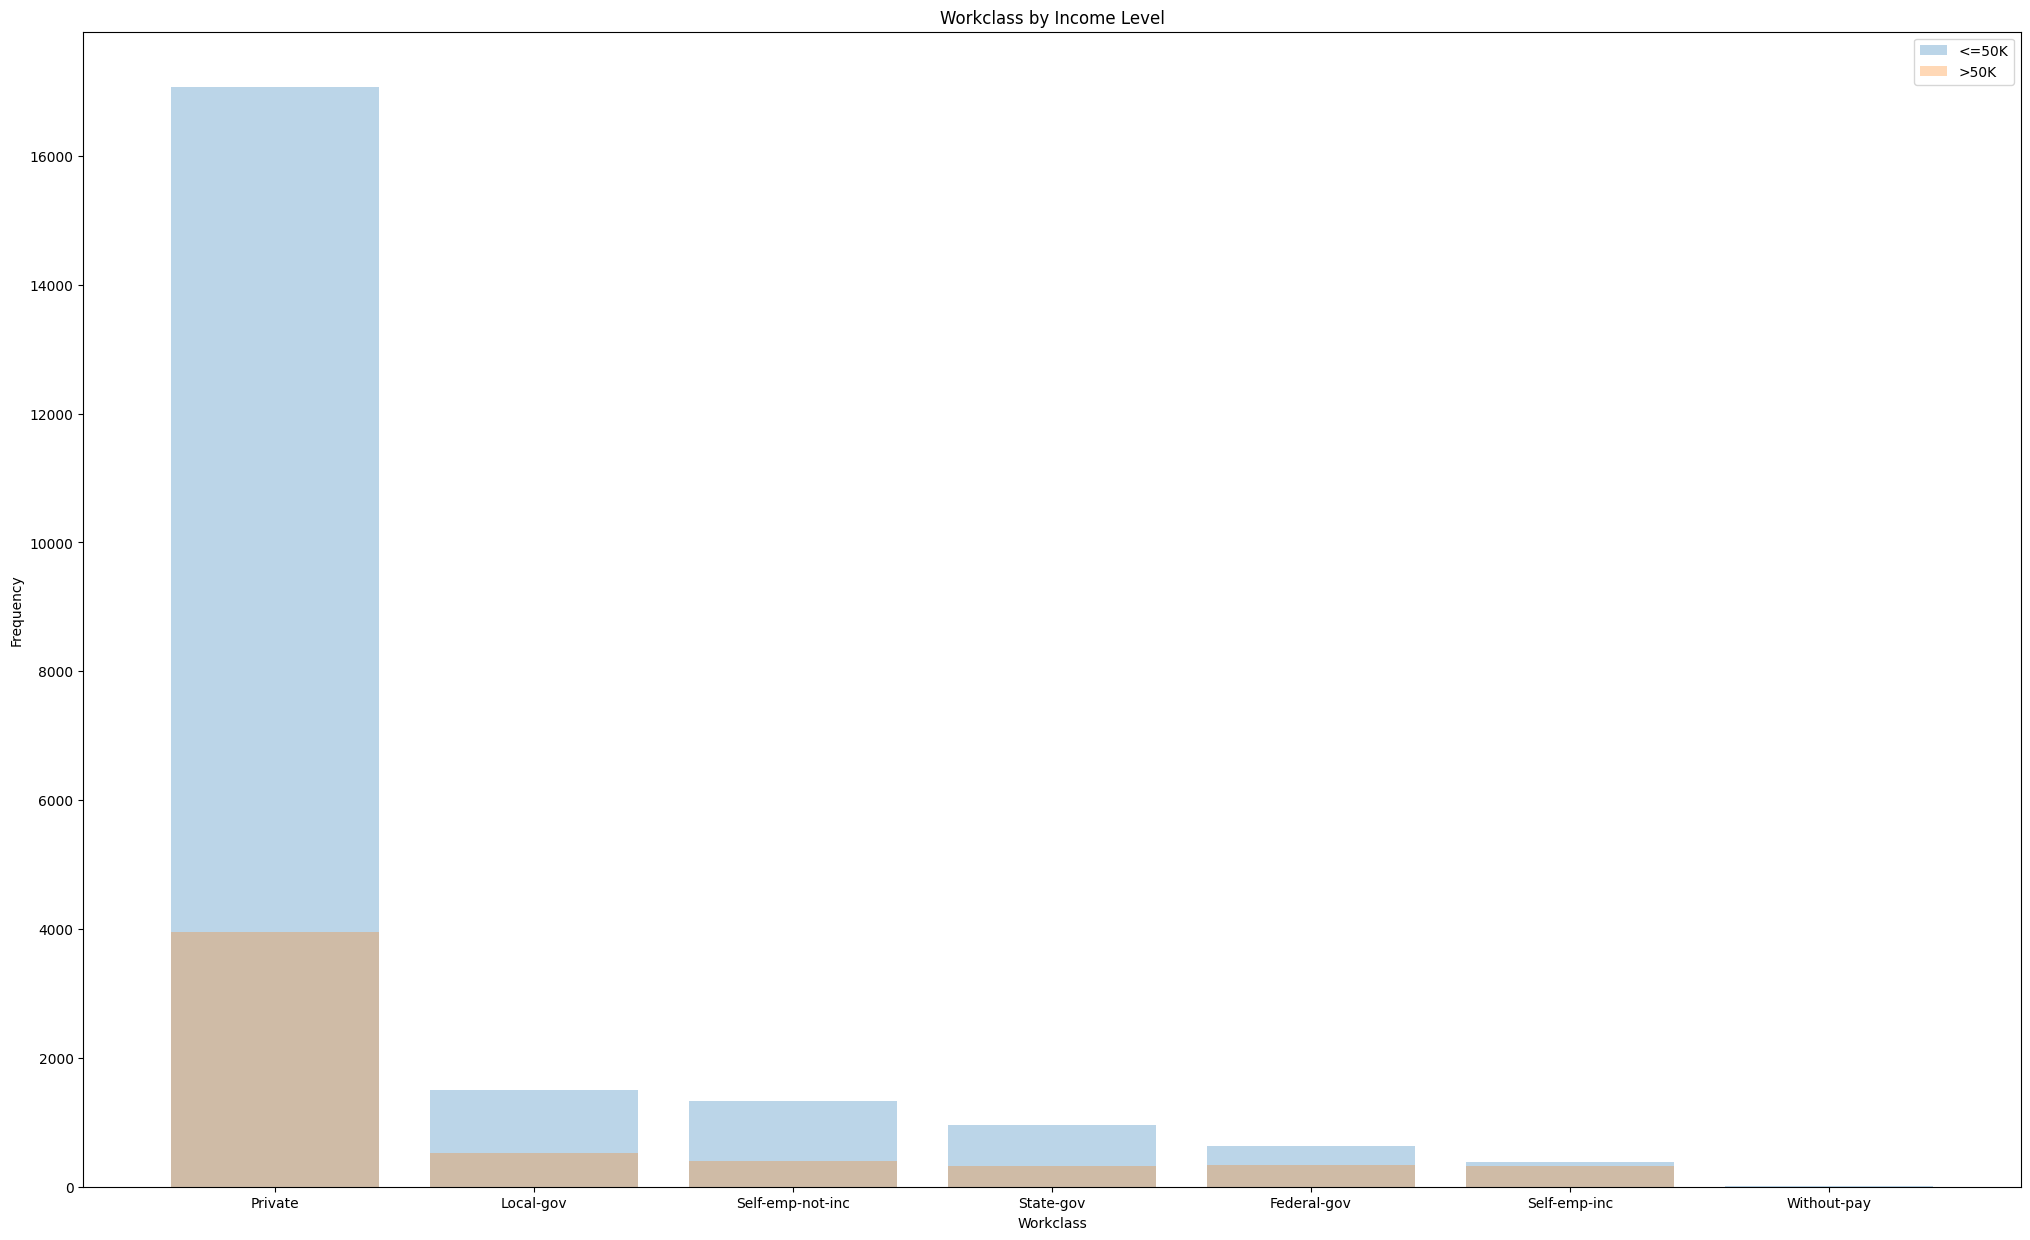

In [ ]:
plt.figure(figsize=(25, 15))
plt.bar(dataset_no_outliers[dataset_no_outliers['numeric-income'] == 0]['workclass'].value_counts().index,
        dataset_no_outliers[dataset_no_outliers['numeric-income'] == 0]['workclass'].value_counts(),
        alpha=0.3, label='<=50K')

plt.bar(dataset_no_outliers[dataset_no_outliers['numeric-income'] == 1]['workclass'].value_counts().index,
        dataset_no_outliers[dataset_no_outliers['numeric-income'] == 1]['workclass'].value_counts(),
        alpha=0.3, label='>50K')

plt.xlabel('Workclass')
plt.ylabel('Frequency')
plt.title('Workclass by Income Level')
plt.legend()

plt.show()

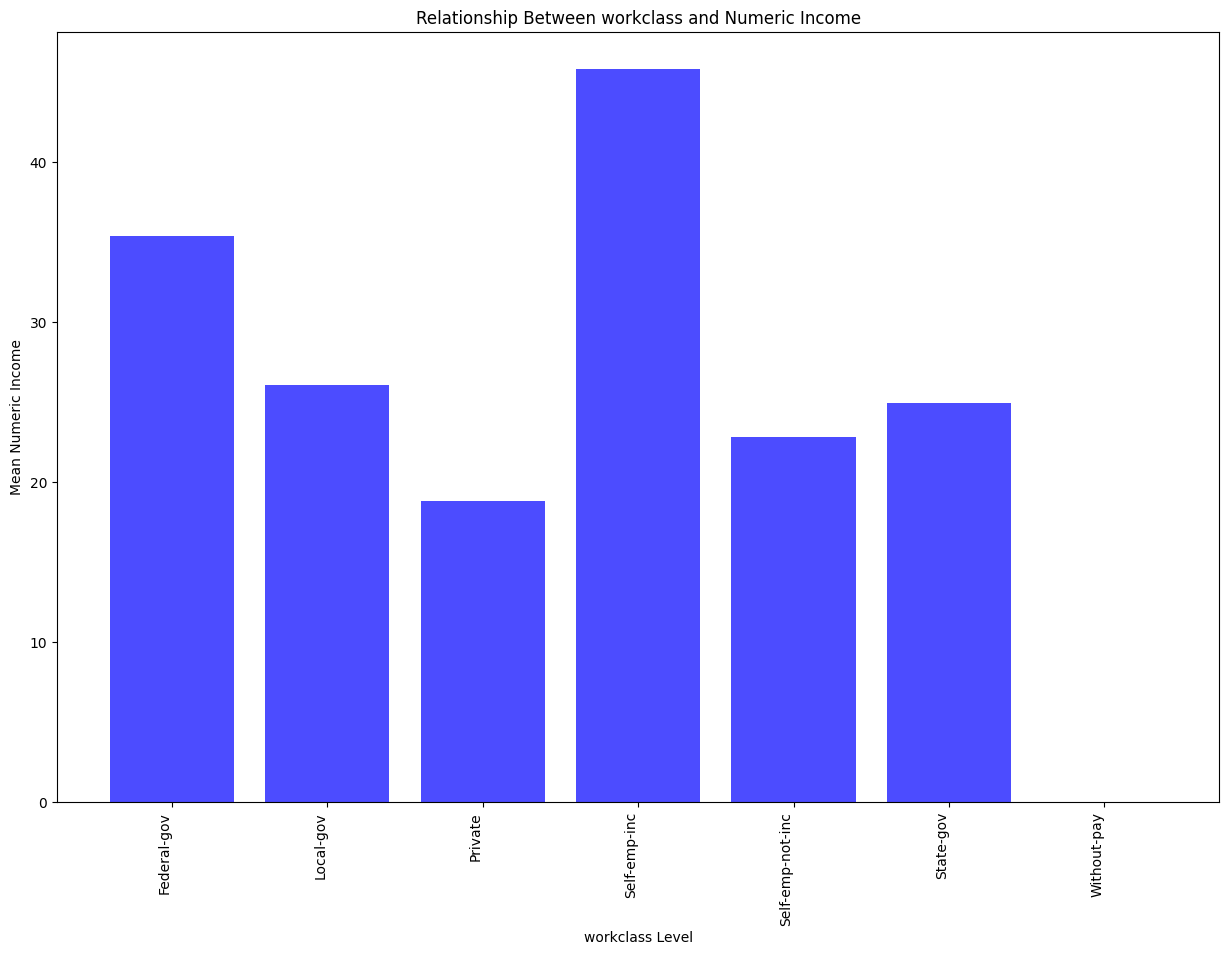

In [ ]:
education_means = 100*dataset_no_outliers.groupby('workclass')['numeric-income'].mean()

# Create a bar chart
plt.figure(figsize=(15, 10))
plt.bar(education_means.index, education_means, color='blue', alpha=0.7)

plt.xlabel('workclass Level')
plt.ylabel('Mean Numeric Income')
plt.title('Relationship Between workclass and Numeric Income')
plt.xticks(rotation=90, ha='right')  # Rotate x-axis labels for better readability

plt.show()

## Distribution of education with income per annual.

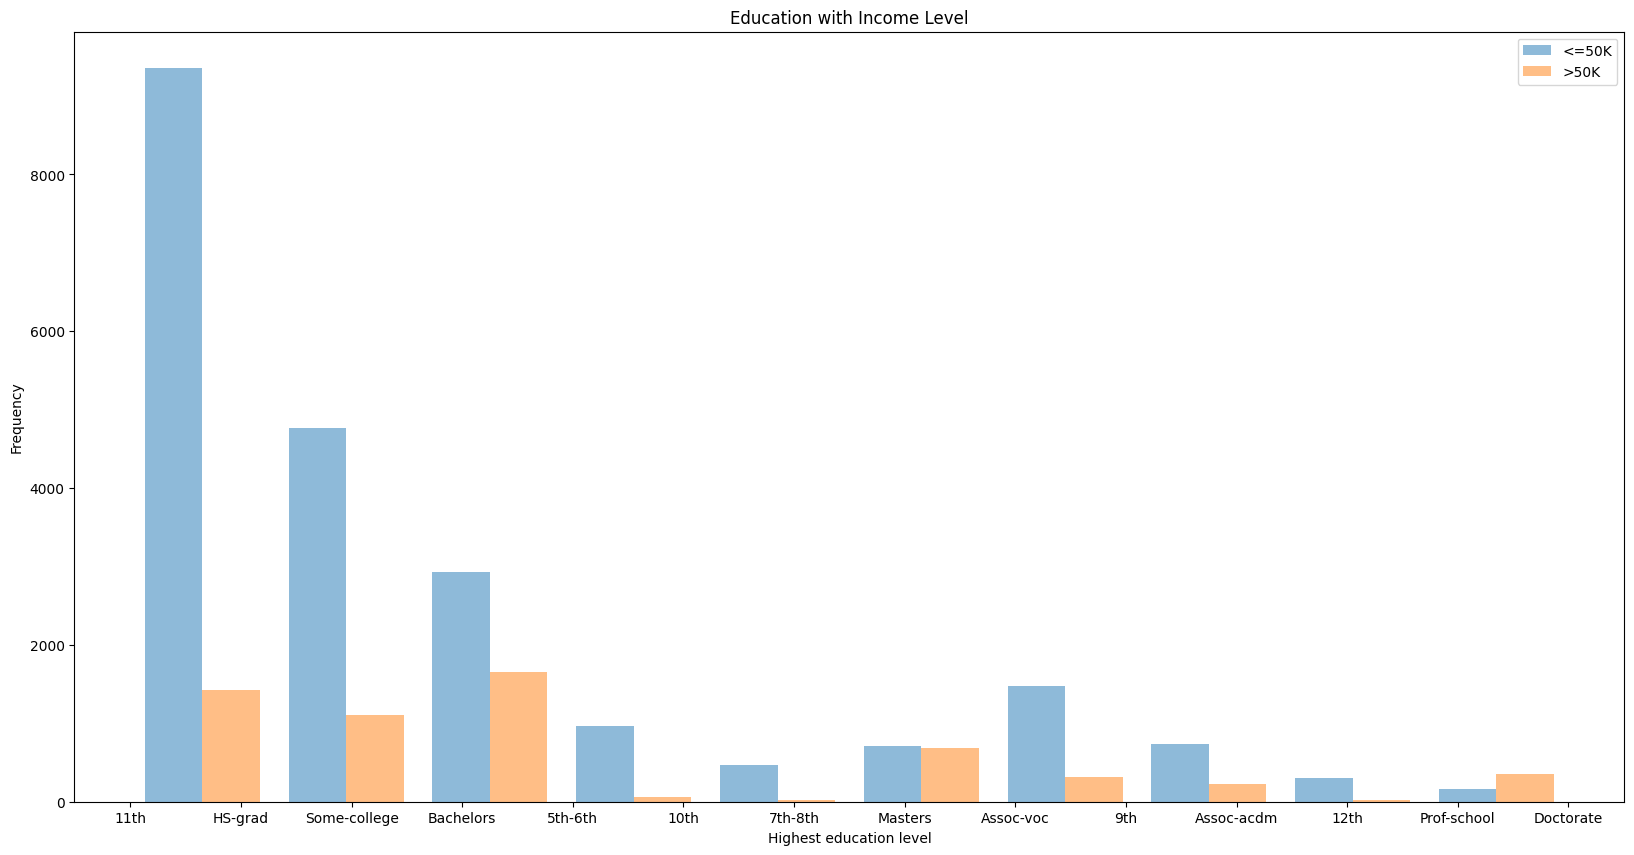

In [ ]:
plt.figure(figsize=(20, 10))
plt.hist([dataset_no_outliers[dataset_no_outliers['numeric-income'] == 0]['education'], dataset_no_outliers[dataset_no_outliers['numeric-income'] == 1]['education']],
          alpha=0.5, label=['<=50K', '>50K'])

plt.xlabel('Highest education level')
plt.ylabel('Frequency')
plt.title('Education with Income Level')
plt.legend()

plt.show()

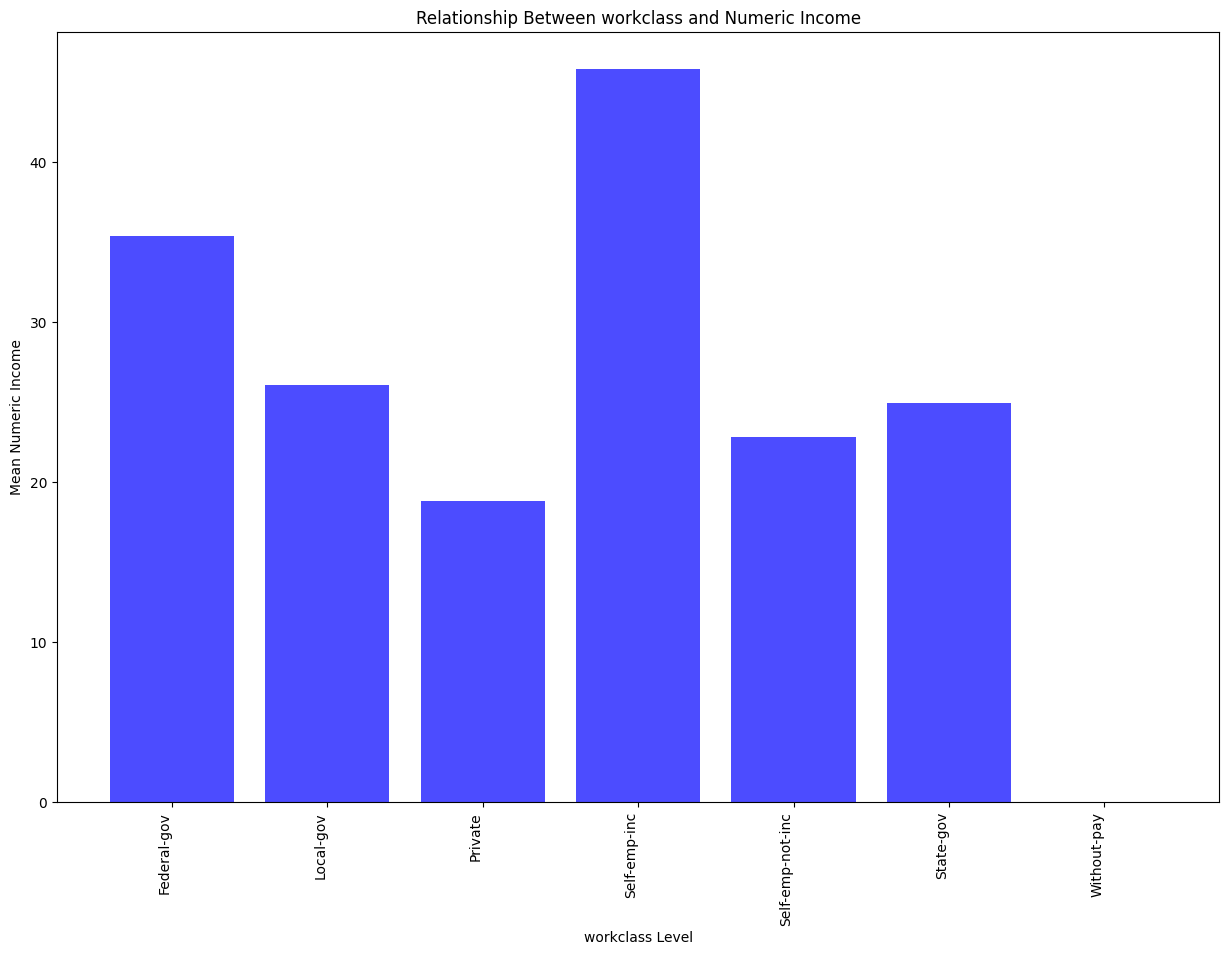

In [ ]:
education_means = 100*dataset_no_outliers.groupby('workclass')['numeric-income'].mean()

# Create a bar chart
plt.figure(figsize=(15, 10))
plt.bar(education_means.index, education_means, color='blue', alpha=0.7)

plt.xlabel('workclass Level')
plt.ylabel('Mean Numeric Income')
plt.title('Relationship Between workclass and Numeric Income')
plt.xticks(rotation=90, ha='right')  # Rotate x-axis labels for better readability

plt.show()

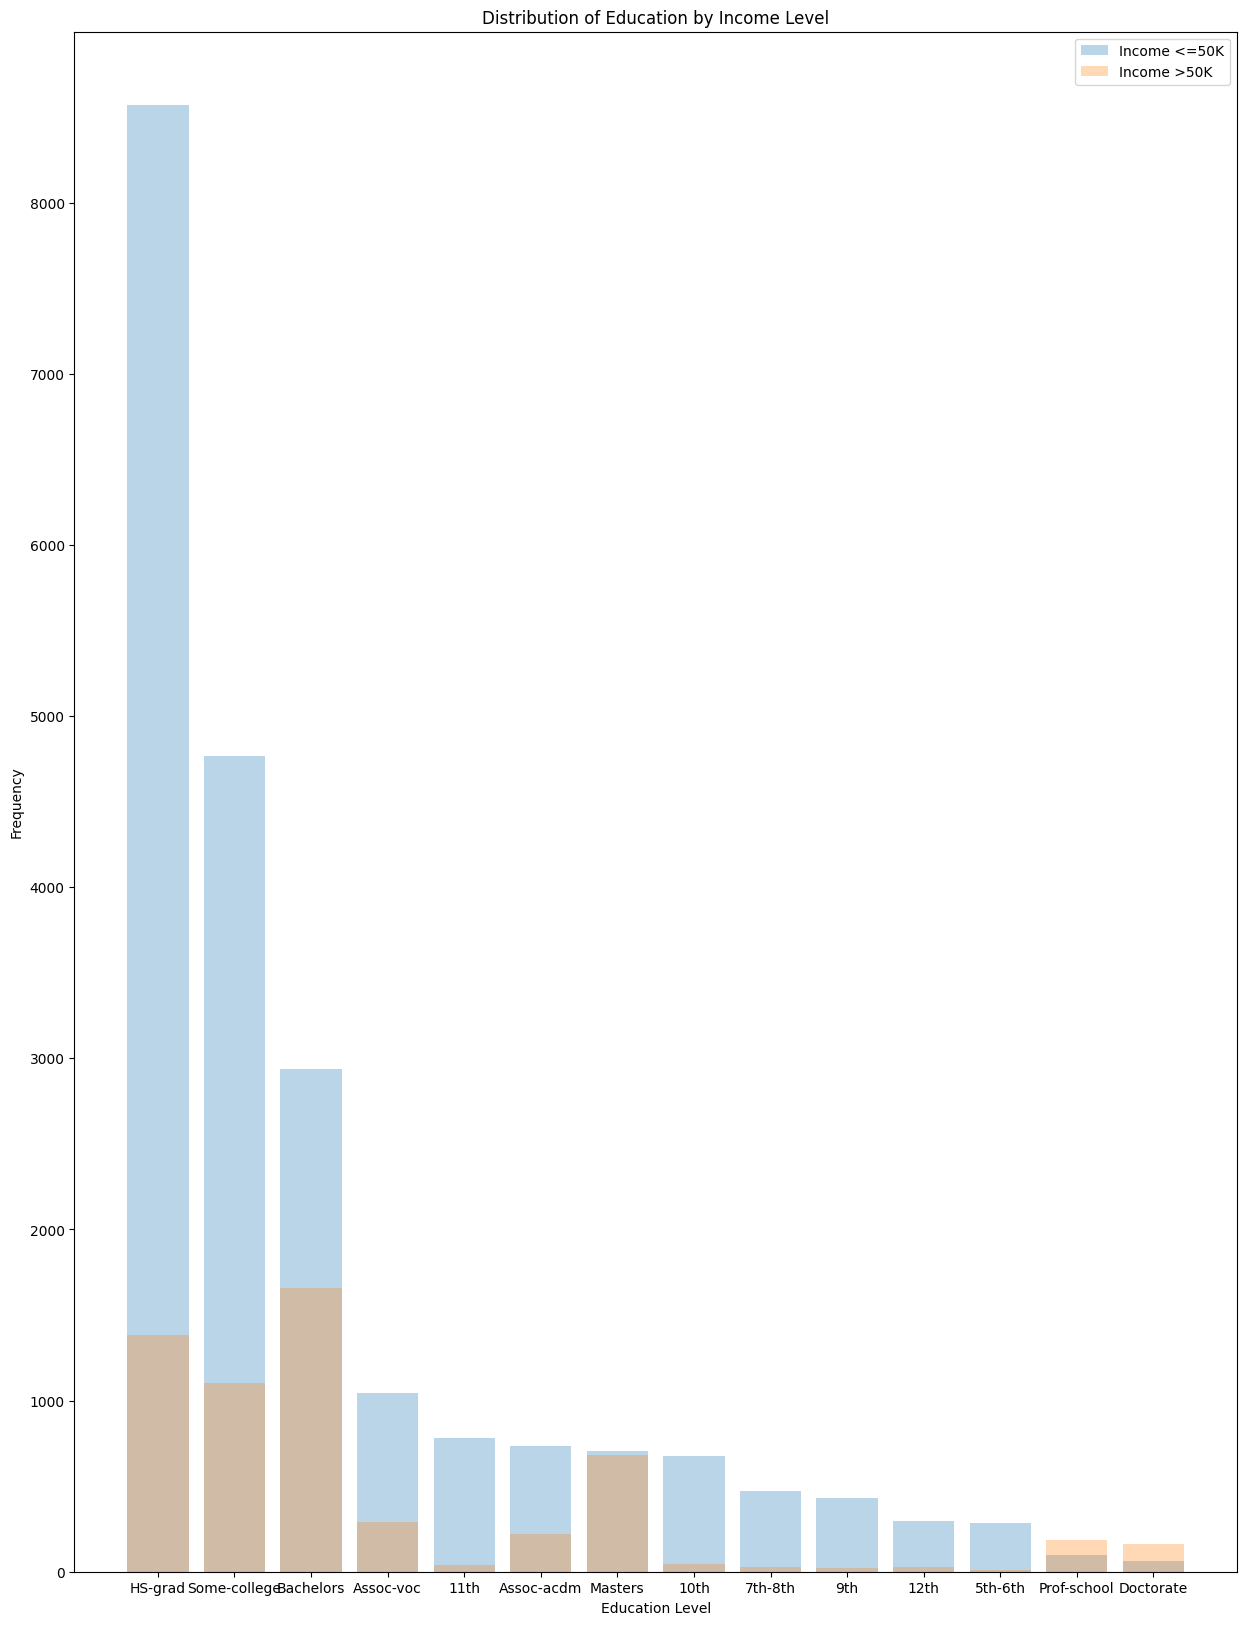

In [ ]:
plt.figure(figsize=(15, 20))
for income_level in [0, 1]:
    education_counts = dataset_no_outliers[dataset_no_outliers['numeric-income'] == income_level]['education'].value_counts()
    plt.bar(education_counts.index, education_counts, alpha=0.3, label=f'Income {">50K" if income_level == 1 else "<=50K"}')

plt.xlabel('Education Level')
plt.ylabel('Frequency')
plt.title('Distribution of Education by Income Level')
plt.legend()

plt.show()

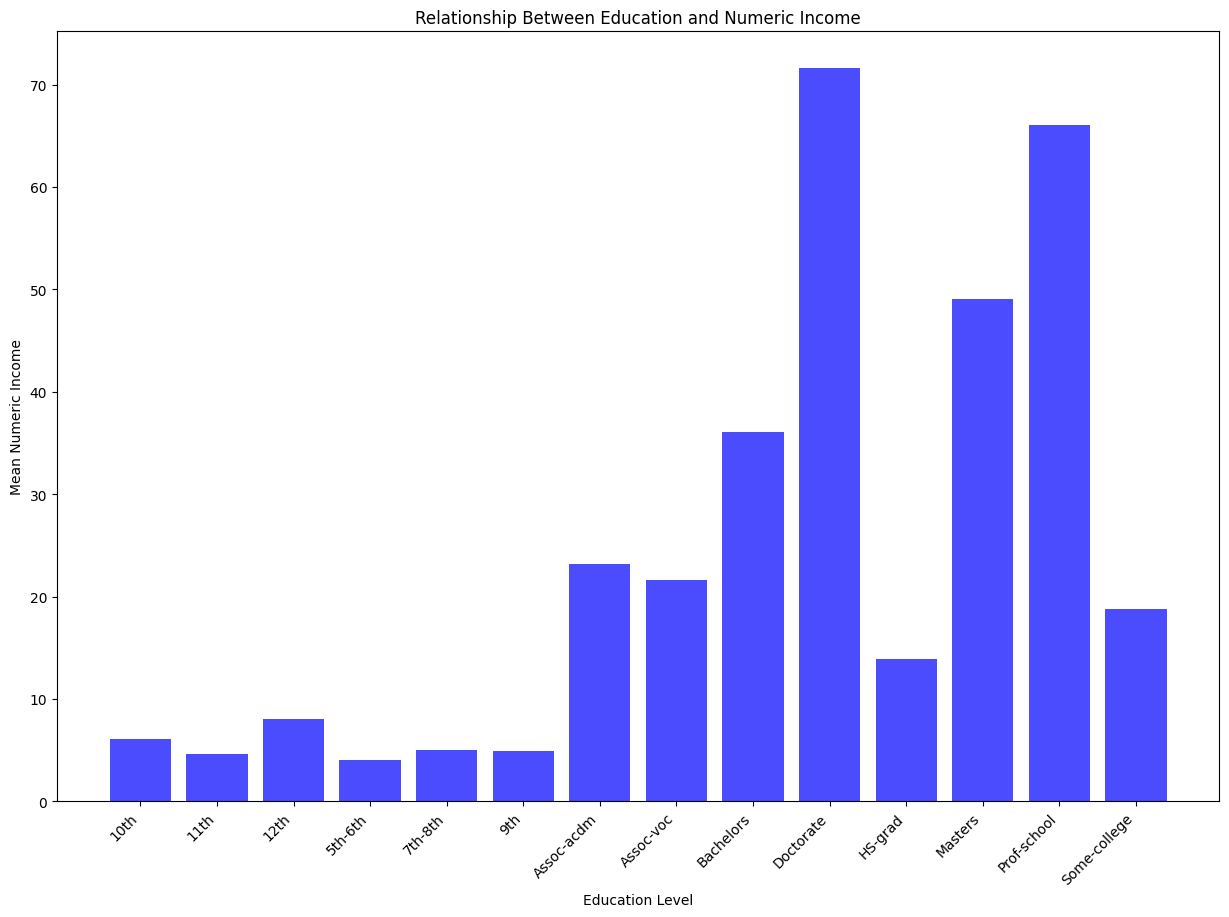

In [ ]:
education_means = 100*dataset_no_outliers.groupby('education')['numeric-income'].mean()

# Create a bar chart
plt.figure(figsize=(15, 10))
plt.bar(education_means.index, education_means, color='blue', alpha=0.7)

plt.xlabel('Education Level')
plt.ylabel('Mean Numeric Income')
plt.title('Relationship Between Education and Numeric Income')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability

plt.show()

## Distribution of education-number with income per annual.

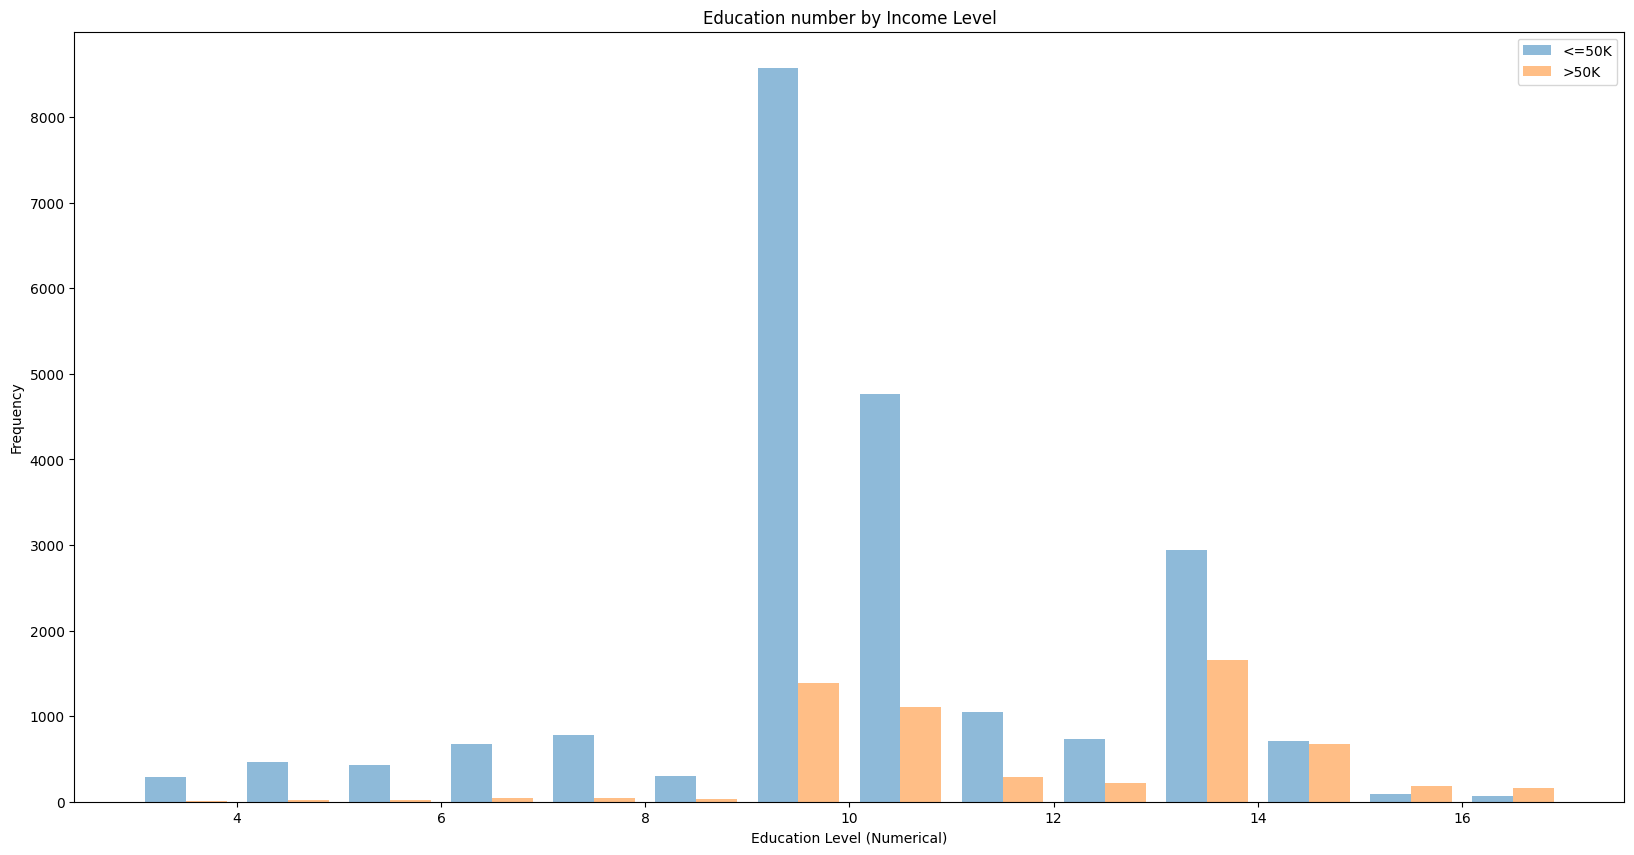

In [ ]:
plt.figure(figsize=(20, 10))
plt.hist([dataset_no_outliers[dataset_no_outliers['numeric-income'] == 0]['educational-num'],
          dataset_no_outliers[dataset_no_outliers['numeric-income'] == 1]['educational-num']],
         bins=range(dataset_no_outliers['educational-num'].min(), dataset_no_outliers['educational-num'].max() + 2),
         alpha=0.5, label=['<=50K', '>50K'])

plt.xlabel('Education Level (Numerical)')
plt.ylabel('Frequency')
plt.title('Education number by Income Level')
plt.legend()

plt.show()

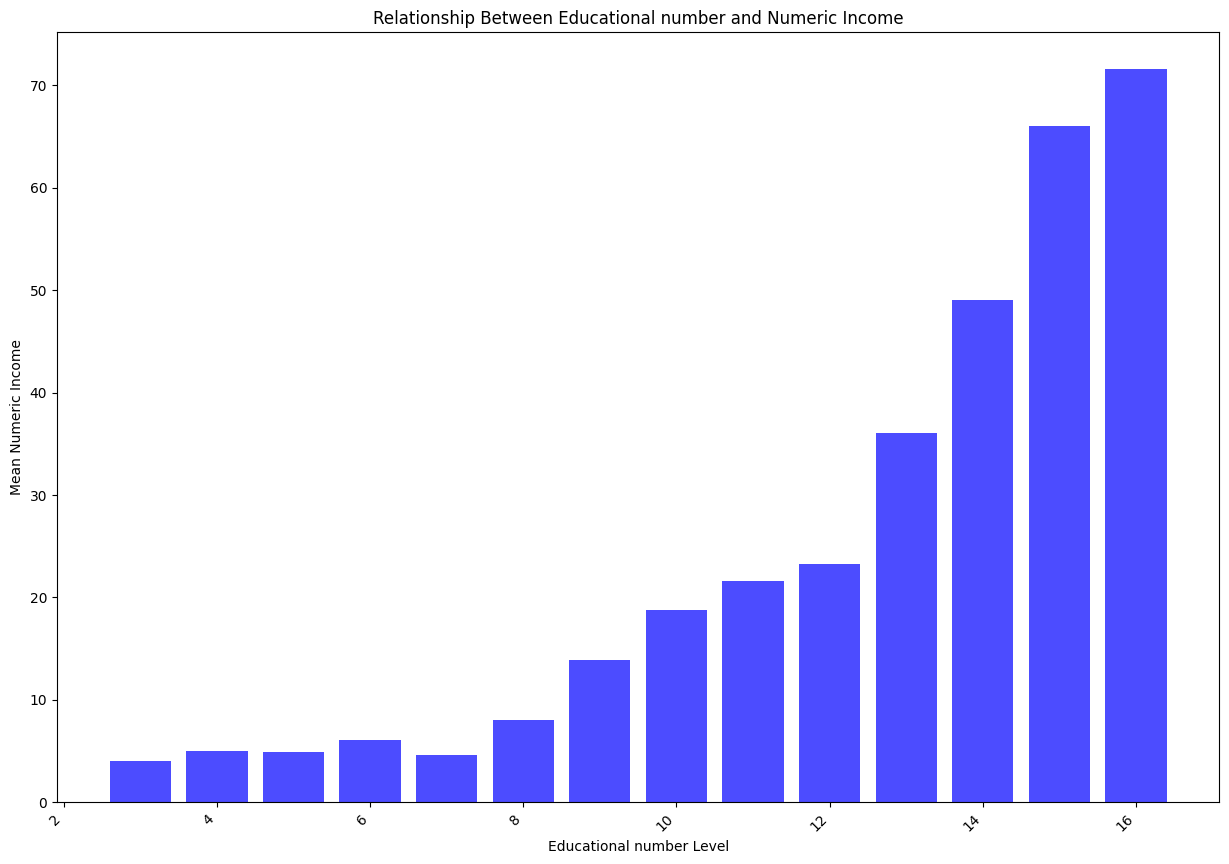

In [ ]:
education_means = 100*dataset_no_outliers.groupby('educational-num')['numeric-income'].mean()

# Create a bar chart
plt.figure(figsize=(15, 10))
plt.bar(education_means.index, education_means, color='blue', alpha=0.7)

plt.xlabel('Educational number Level')
plt.ylabel('Mean Numeric Income')
plt.title('Relationship Between Educational number and Numeric Income')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability

plt.show()

## Distribution of marital status with income per annual.

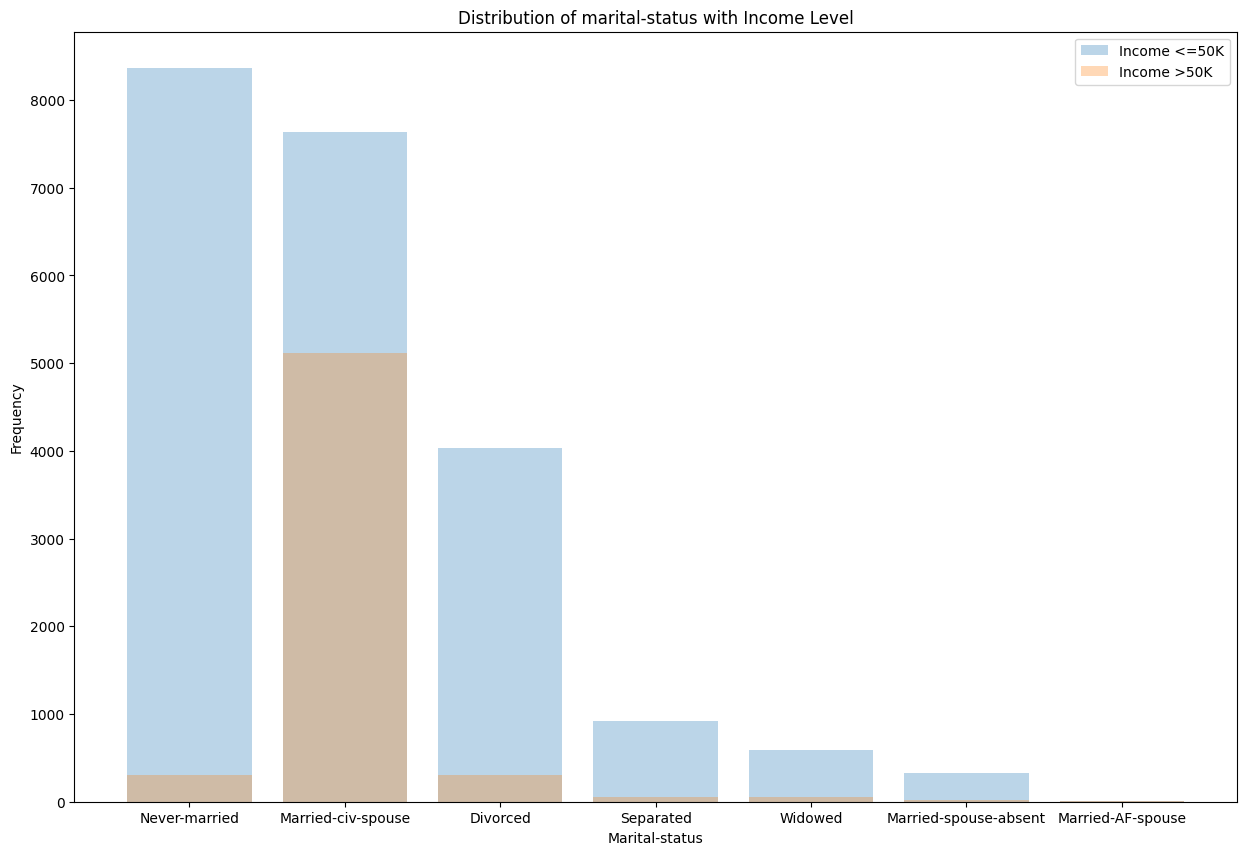

In [ ]:
plt.figure(figsize=(15, 10))
for income_level in [0, 1]:
    education_counts = dataset_no_outliers[dataset_no_outliers['numeric-income'] == income_level]['marital-status'].value_counts()
    plt.bar(education_counts.index, education_counts, alpha=0.3, label=f'Income {">50K" if income_level == 1 else "<=50K"}')

plt.xlabel('Marital-status')
plt.ylabel('Frequency')
plt.title('Distribution of marital-status with Income Level')
plt.legend()

plt.show()

## Distribution of occupation with income per annual.

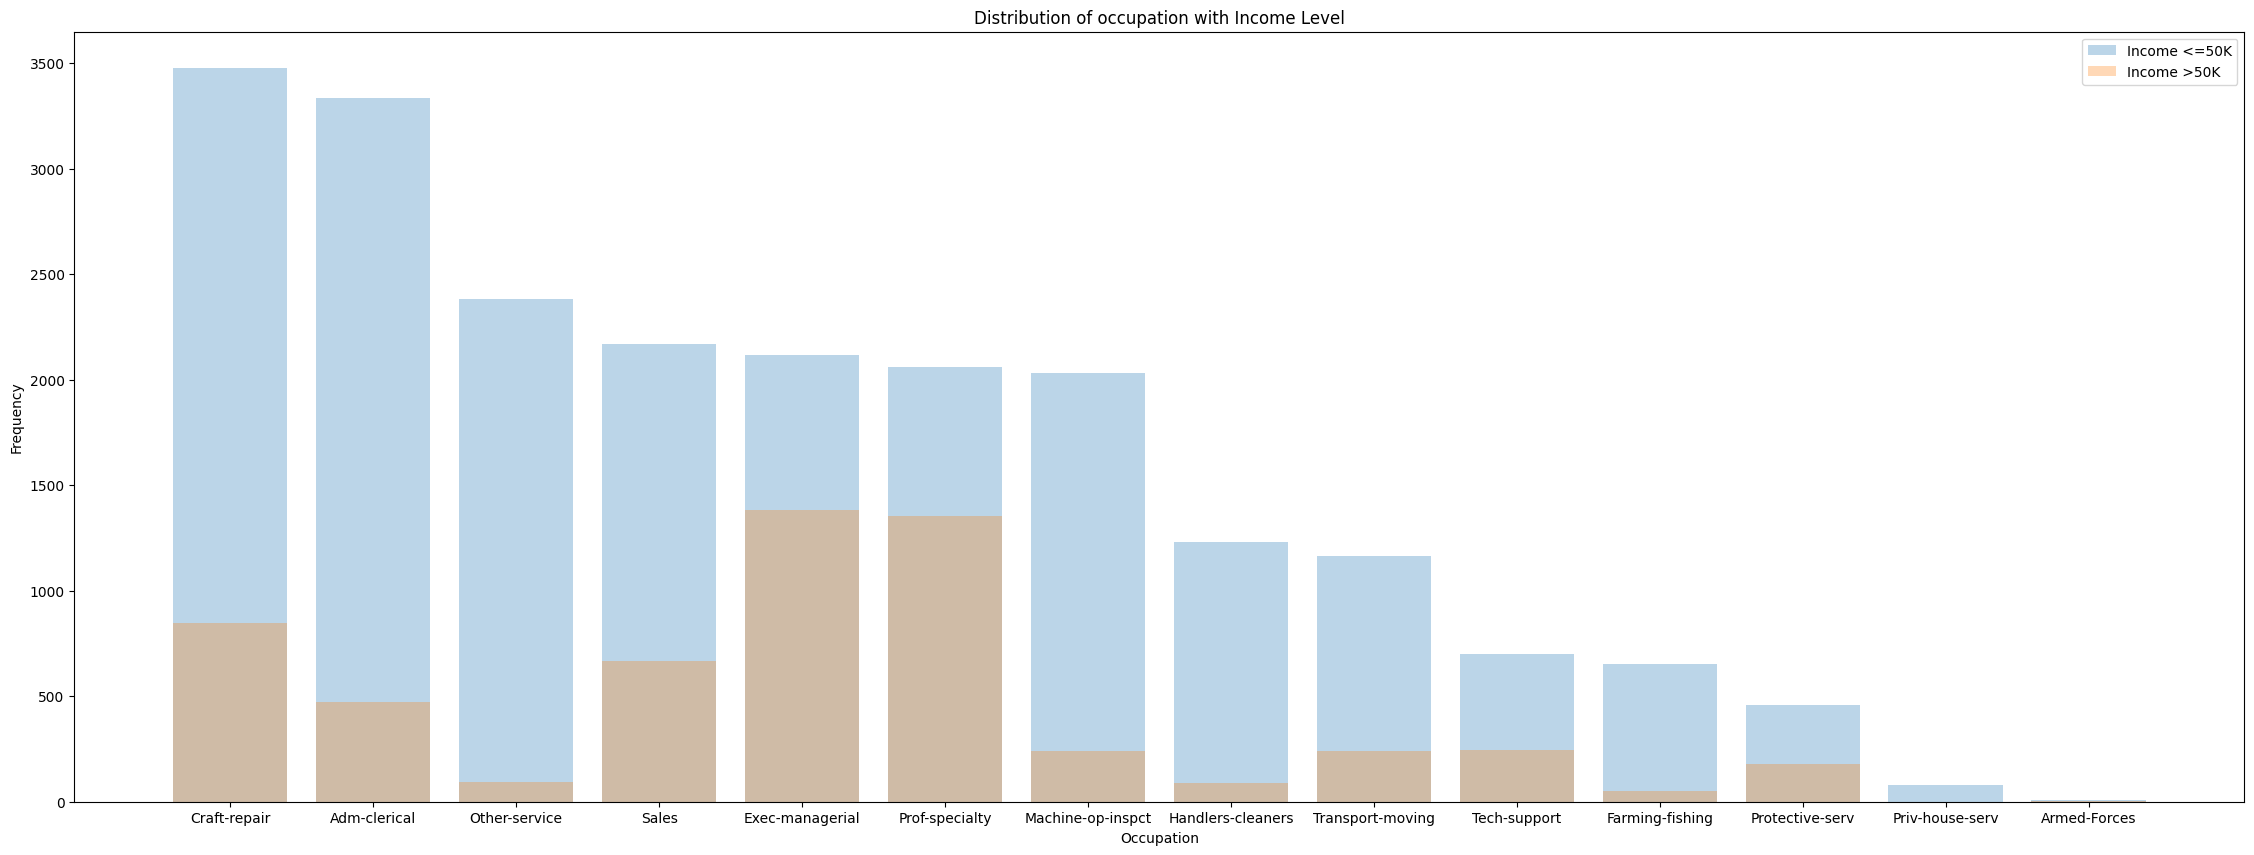

In [ ]:
plt.figure(figsize=(28, 10))
for income_level in [0, 1]:
    education_counts = dataset_no_outliers[dataset_no_outliers['numeric-income'] == income_level]['occupation'].value_counts()
    plt.bar(education_counts.index, education_counts, alpha=0.3, label=f'Income {">50K" if income_level == 1 else "<=50K"}')

plt.xlabel('Occupation')
plt.ylabel('Frequency')
plt.title('Distribution of occupation with Income Level')
plt.legend()

plt.show()

## Distribution of relationship with income per annual.

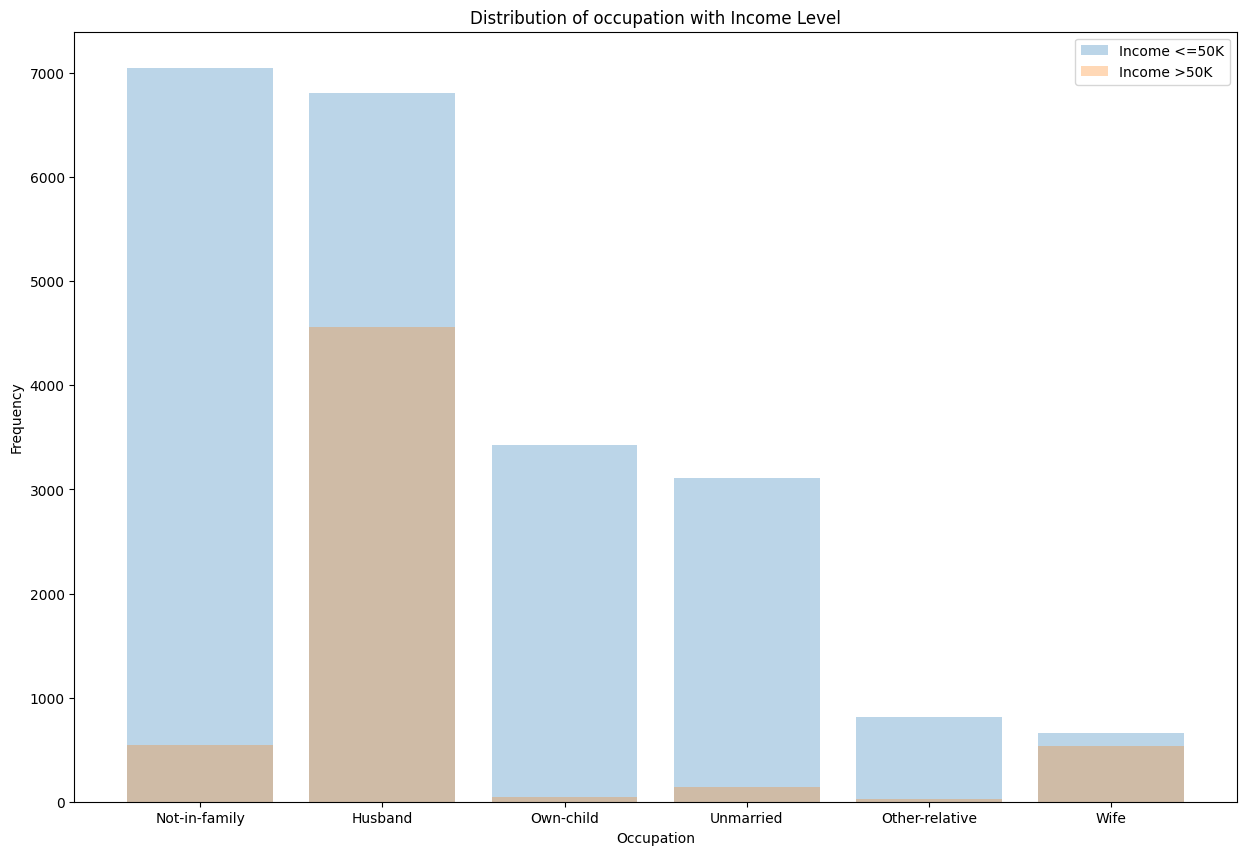

In [ ]:
plt.figure(figsize=(15, 10))
for income_level in [0, 1]:
    education_counts = dataset_no_outliers[dataset_no_outliers['numeric-income'] == income_level]['relationship'].value_counts()
    plt.bar(education_counts.index, education_counts, alpha=0.3, label=f'Income {">50K" if income_level == 1 else "<=50K"}')

plt.xlabel('Occupation')
plt.ylabel('Frequency')
plt.title('Distribution of occupation with Income Level')
plt.legend()

plt.show()

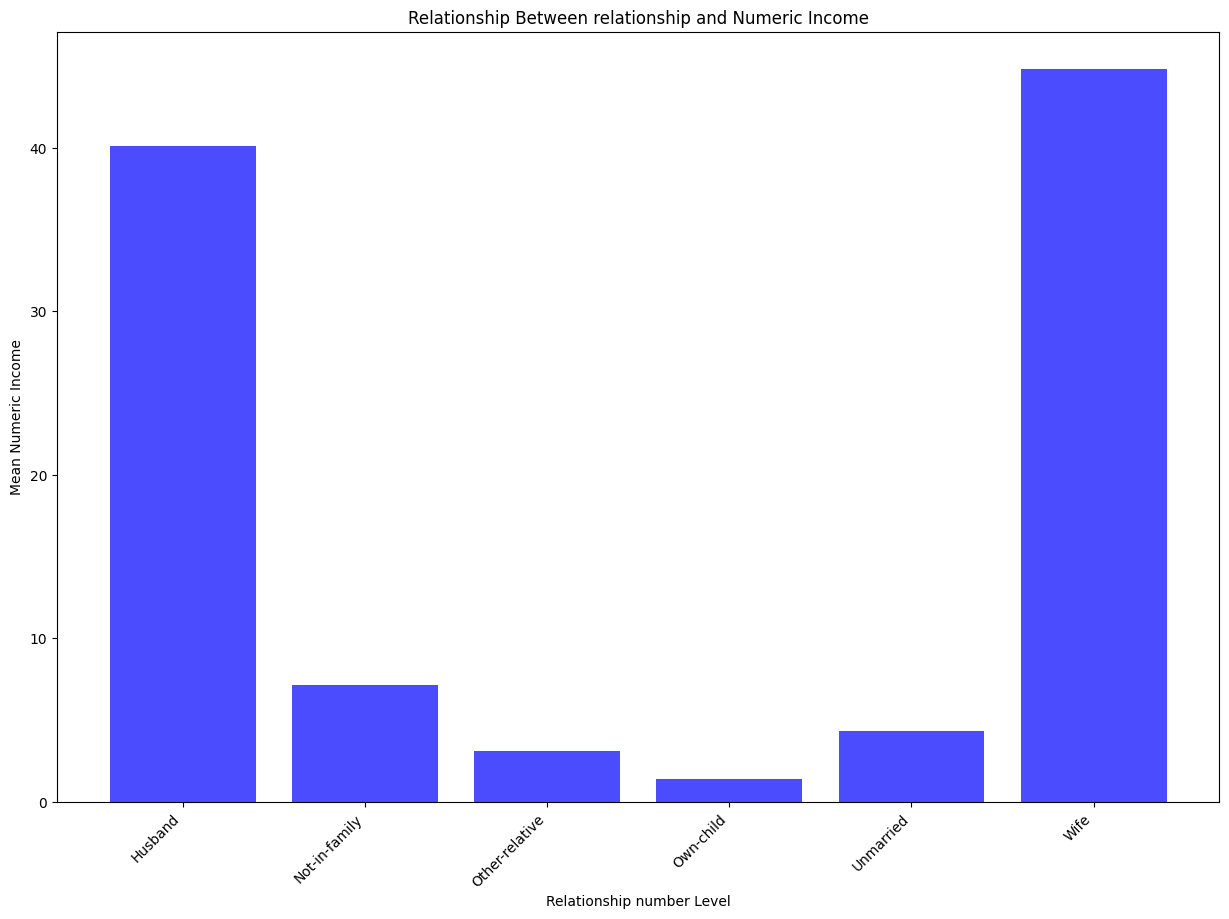

In [ ]:
education_means = 100*dataset_no_outliers.groupby('relationship')['numeric-income'].mean()

# Create a bar chart
plt.figure(figsize=(15, 10))
plt.bar(education_means.index, education_means, color='blue', alpha=0.7)

plt.xlabel('Relationship number Level')
plt.ylabel('Mean Numeric Income')
plt.title('Relationship Between relationship and Numeric Income')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability

plt.show()

## Distribution of race with income per annual.

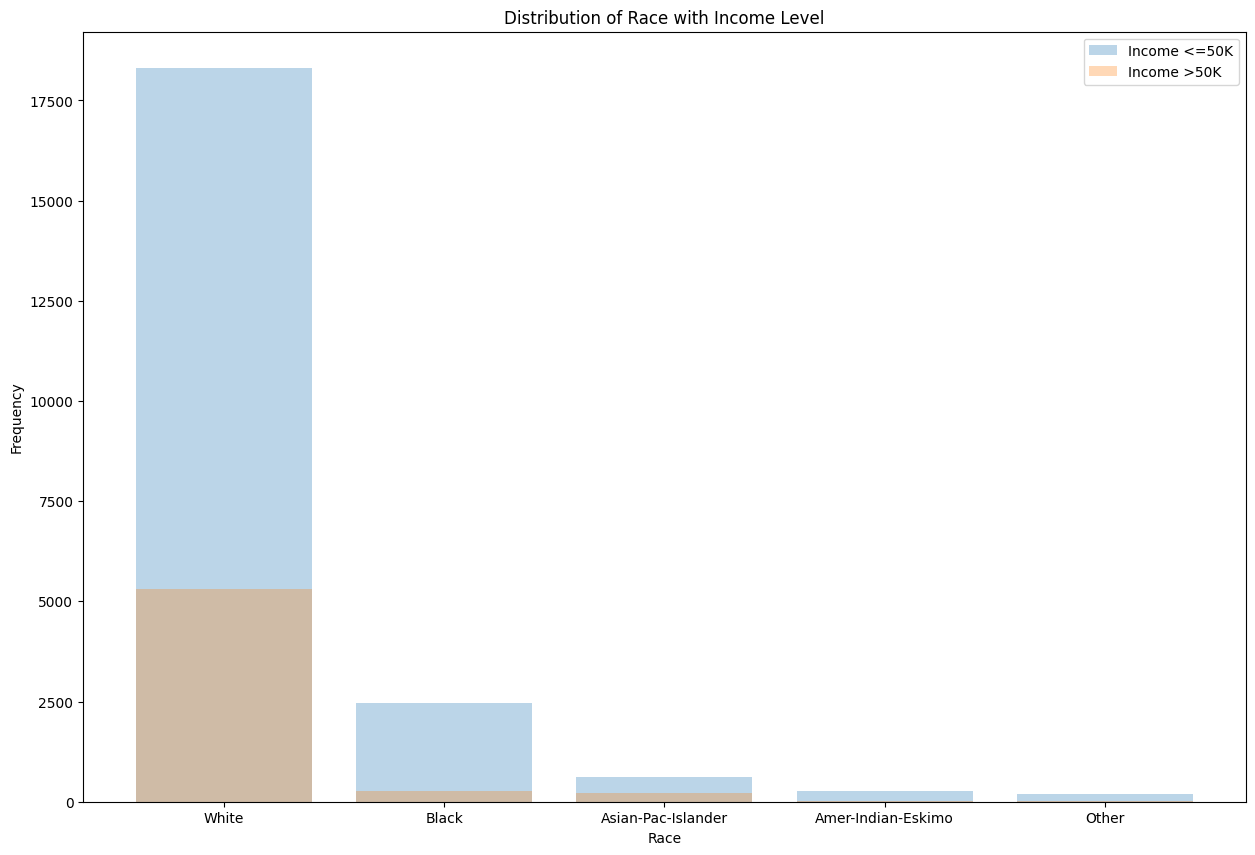

In [ ]:
plt.figure(figsize=(15, 10))
for income_level in [0, 1]:
    education_counts = dataset_no_outliers[dataset_no_outliers['numeric-income'] == income_level]['race'].value_counts()
    plt.bar(education_counts.index, education_counts, alpha=0.3, label=f'Income {">50K" if income_level == 1 else "<=50K"}')

plt.xlabel('Race')
plt.ylabel('Frequency')
plt.title('Distribution of Race with Income Level')
plt.legend()

plt.show()

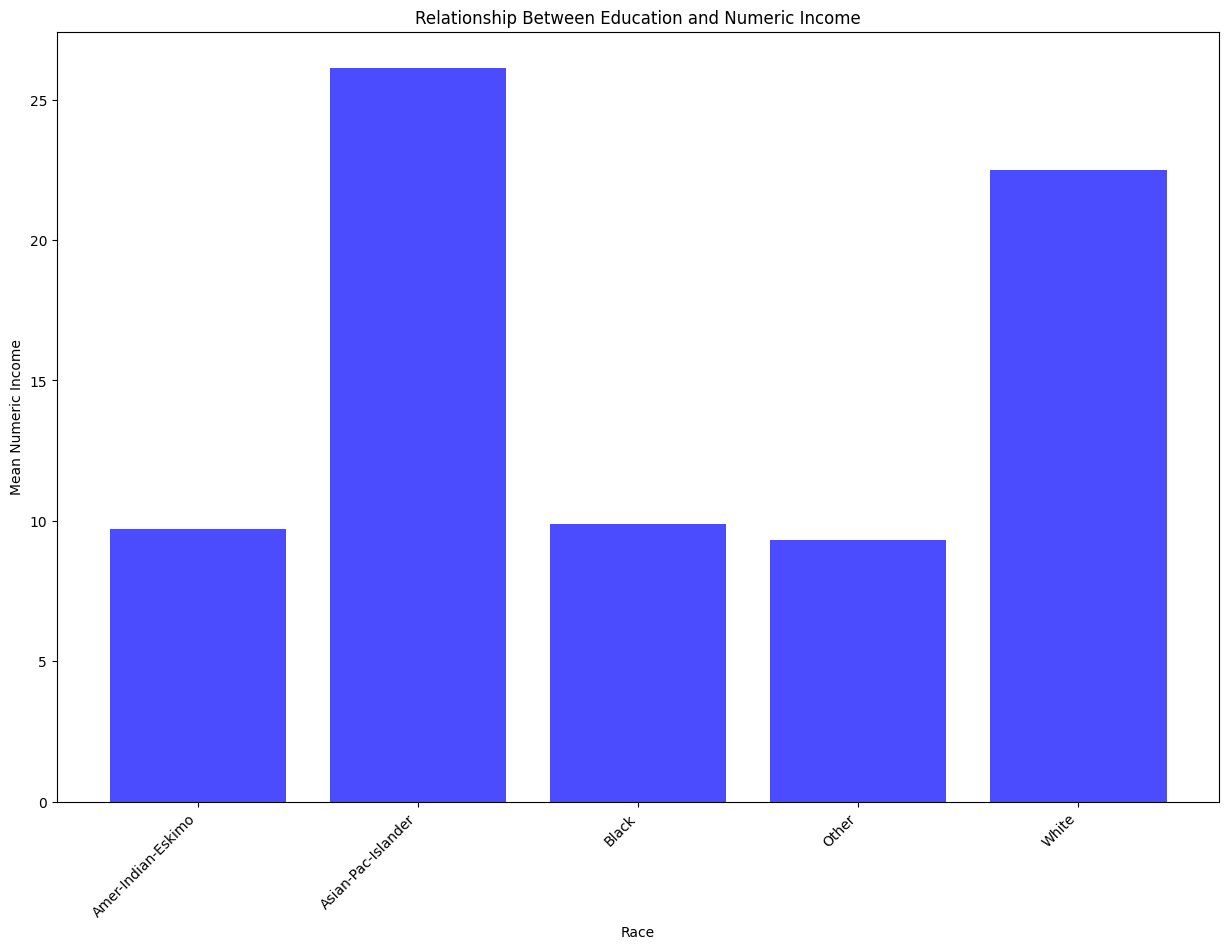

In [ ]:
education_means = 100*dataset_no_outliers.groupby('race')['numeric-income'].mean()

# Create a bar chart
plt.figure(figsize=(15, 10))
plt.bar(education_means.index, education_means, color='blue', alpha=0.7)

plt.xlabel('Race')
plt.ylabel('Mean Numeric Income')
plt.title('Relationship Between Education and Numeric Income')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability

plt.show()

## Distribution of gender with income per annual.

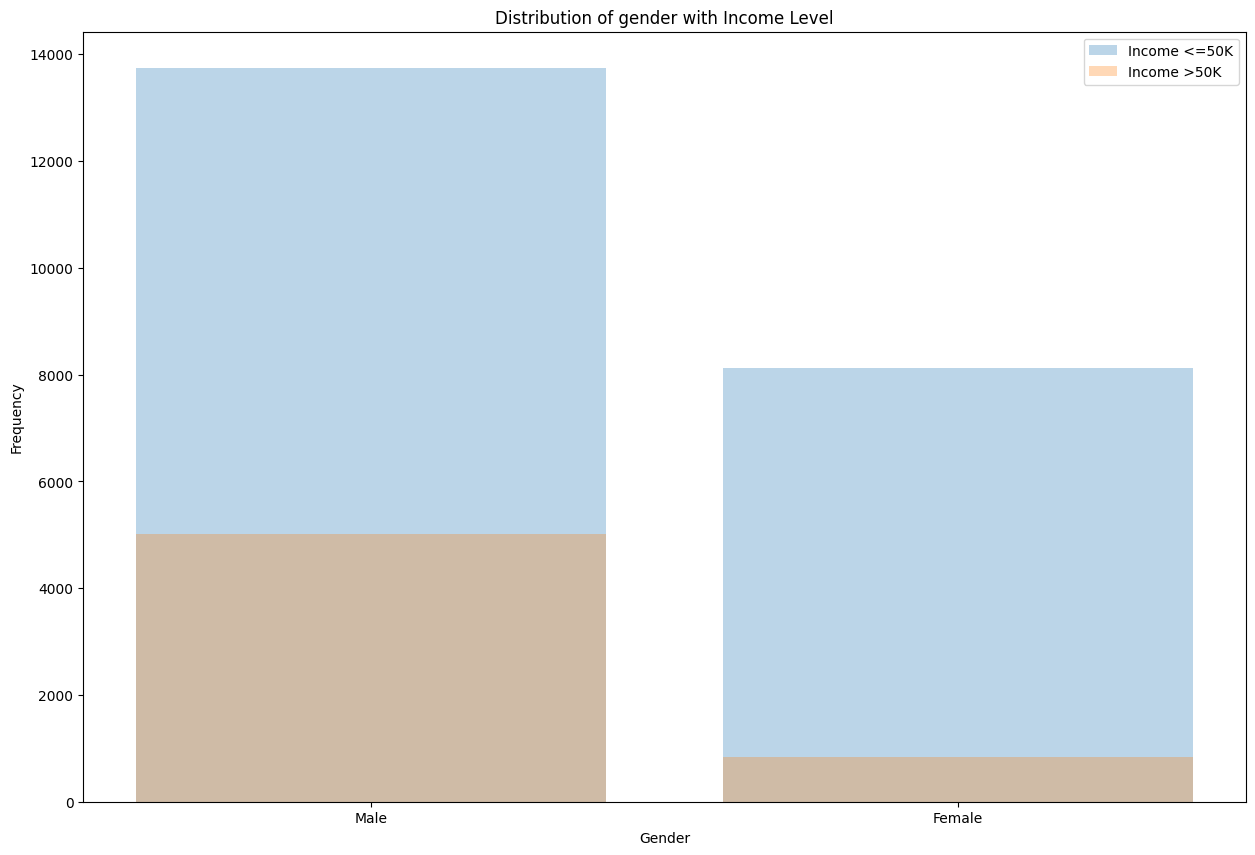

In [ ]:
plt.figure(figsize=(15, 10))
for income_level in [0, 1]:
    education_counts = dataset_no_outliers[dataset_no_outliers['numeric-income'] == income_level]['gender'].value_counts()
    plt.bar(education_counts.index, education_counts, alpha=0.3, label=f'Income {">50K" if income_level == 1 else "<=50K"}')

plt.xlabel('Gender')
plt.ylabel('Frequency')
plt.title('Distribution of gender with Income Level')
plt.legend()

plt.show()

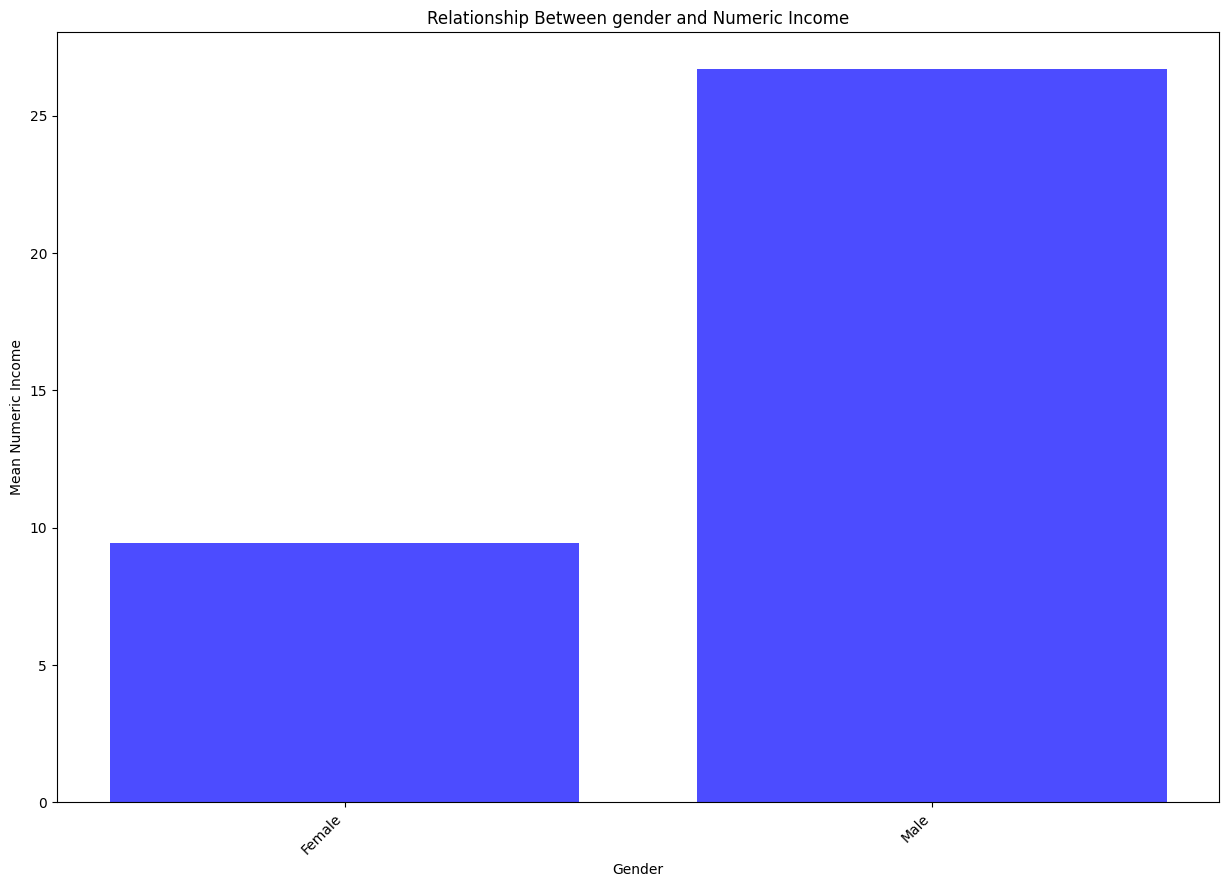

In [ ]:
education_means = 100*dataset_no_outliers.groupby('gender')['numeric-income'].mean()

# Create a bar chart
plt.figure(figsize=(15, 10))
plt.bar(education_means.index, education_means, color='blue', alpha=0.7)

plt.xlabel('Gender')
plt.ylabel('Mean Numeric Income')
plt.title('Relationship Between gender and Numeric Income')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability

plt.show()

## Distribution of working hour per week with income per annual.

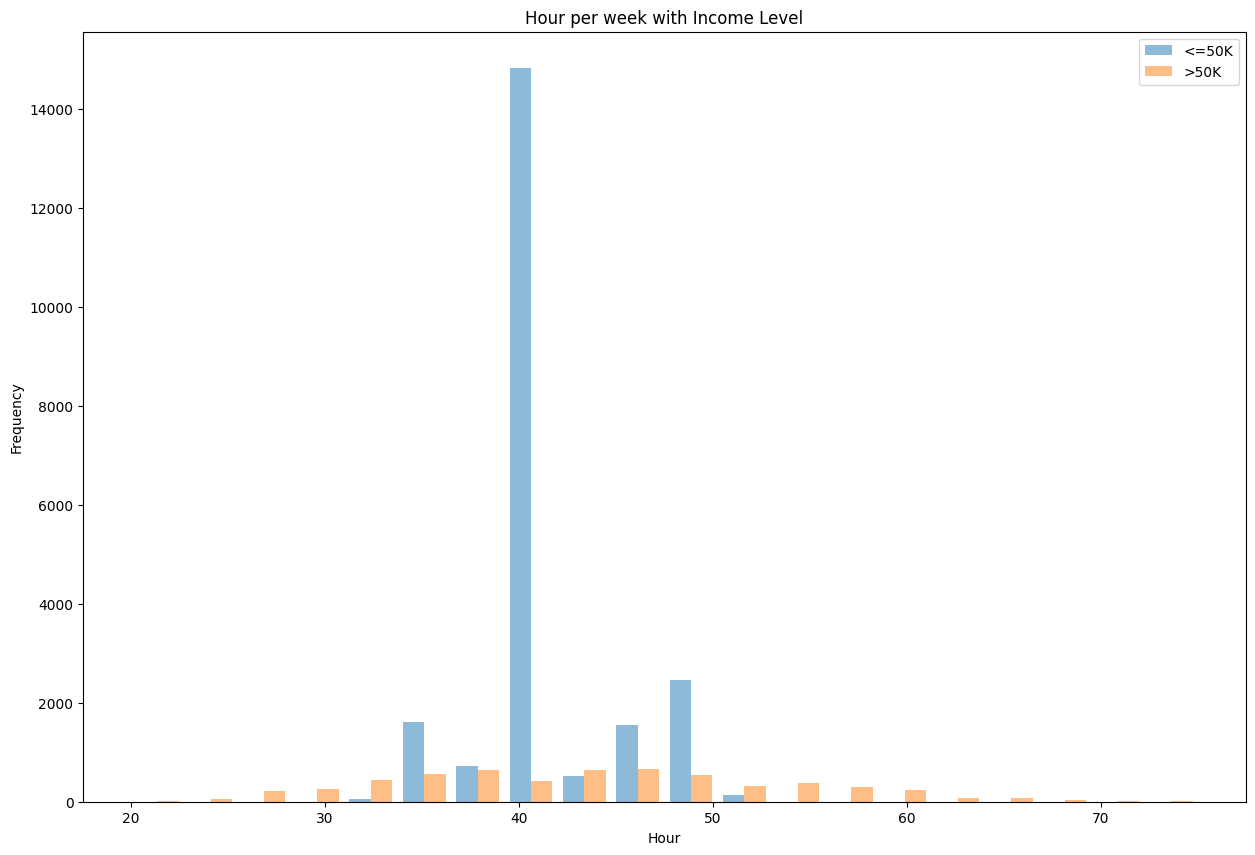

In [ ]:
plt.figure(figsize=(15, 10))
plt.hist([dataset_no_outliers[dataset_no_outliers['numeric-income'] == 0]['hours-per-week'], dataset_no_outliers[dataset_no_outliers['numeric-income'] == 1]['age']],
         bins=20, alpha=0.5, label=['<=50K', '>50K'])

plt.xlabel('Hour')
plt.ylabel('Frequency')
plt.title('Hour per week with Income Level')
plt.legend()

plt.show()

## Distribution of native country with income per annual.

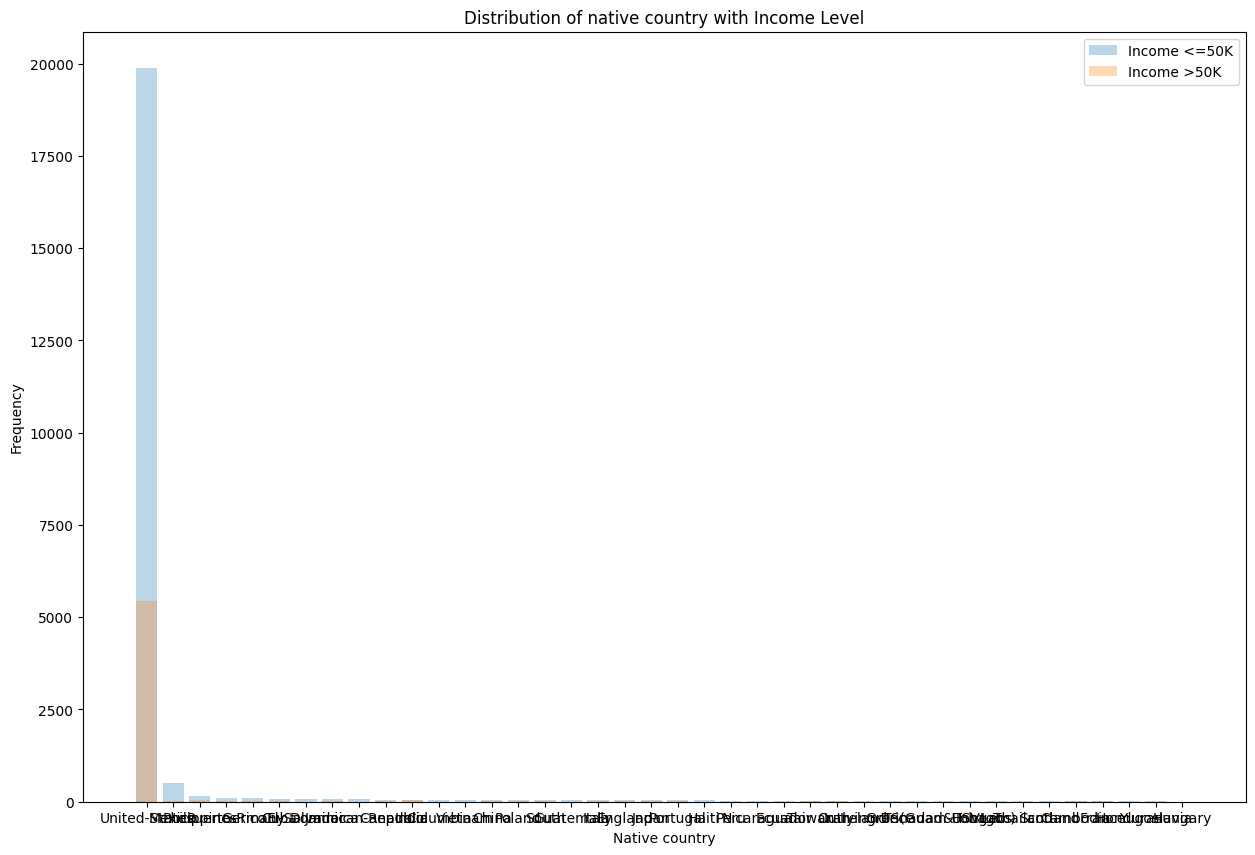

In [ ]:
plt.figure(figsize=(15, 10))
for income_level in [0, 1]:
    education_counts = dataset_no_outliers[dataset_no_outliers['numeric-income'] == income_level]['native-country'].value_counts()
    plt.bar(education_counts.index, education_counts, alpha=0.3, label=f'Income {">50K" if income_level == 1 else "<=50K"}')

plt.xlabel('Native country')
plt.ylabel('Frequency')
plt.title('Distribution of native country with Income Level')
plt.legend()

plt.show()

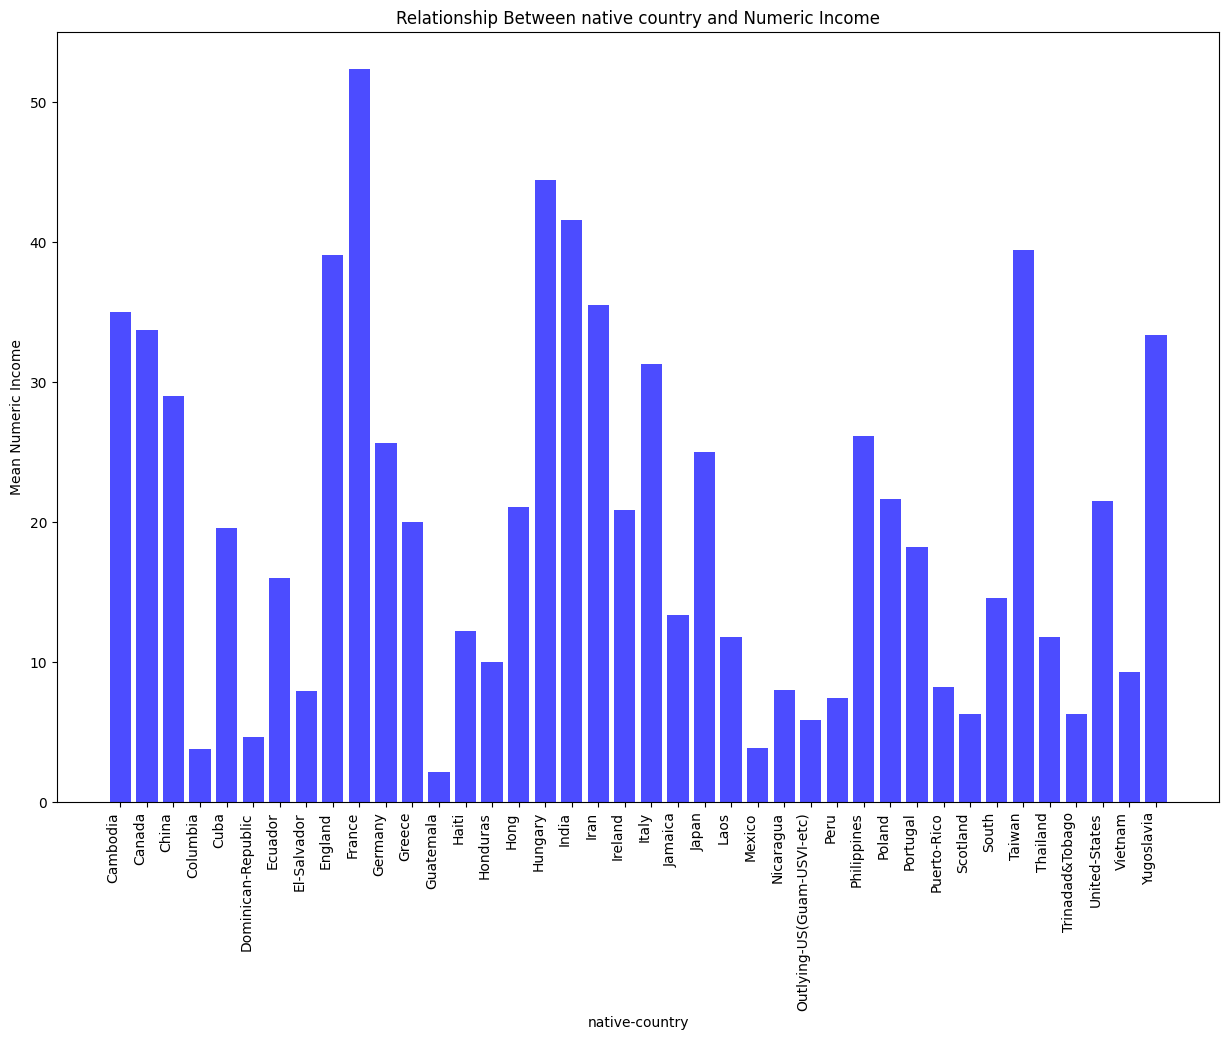

In [ ]:
education_means = 100*dataset_no_outliers.groupby('native-country')['numeric-income'].mean()

# Create a bar chart
plt.figure(figsize=(15, 10))
plt.bar(education_means.index, education_means, color='blue', alpha=0.7)

plt.xlabel('native-country')
plt.ylabel('Mean Numeric Income')
plt.title('Relationship Between native country and Numeric Income')
plt.xticks(rotation=90, ha='right')  # Rotate x-axis labels for better readability

plt.show()